<a href="https://colab.research.google.com/github/BarshaPanthi7/Danphe_task_Barsha/blob/main/notebooks/02_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## WESAD Dataset

In [ ]:
from google.colab import files

# Upload kaggle.json
files.upload()

In [2]:
import os
import shutil

# Creating  Kaggle configuration directory
os.makedirs("/root/.config/kaggle", exist_ok=True)

# Moving the Kaggle API key to the required location
shutil.move(
    "/content/kaggle.json",
    "/root/.config/kaggle/kaggle.json"
)

# Set secure permissions
os.chmod(
    "/root/.config/kaggle/kaggle.json",
    0o600
)

print("Kaggle API configured successfully.")

Kaggle API configured successfully.


In [3]:
!pip install -q --upgrade kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 2.7 MB/s eta 0:00:00


In [4]:
!kaggle --version

Kaggle CLI 2.2.4


In [5]:
# Searching for the WESAD dataset
!kaggle datasets list -s wesad

ref                                                    title                                               size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------  --------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
mohamedasem318/wesad-full-dataset                      WESAD - Full Dataset                          2612994853  2025-04-30 22:58:23.297000           3075         27  0.9411765        
orvile/wesad-wearable-stress-affect-detection-dataset  WESAD (Wearable Stress and Affect Detection)  2612988288  2025-04-19 16:45:03.150000          13544         62  1                
qiriro/stress                                          Biometrics for stress monitoring              5623939830  2019-05-12 16:31:04.393000           7322        102  0.7058824        
amineipad/wesad-small-dataset                          Wesad Full Dataset C

In [6]:
# Checking the files available in the WESAD Kaggle dataset
!kaggle datasets files -d orvile/wesad-wearable-stress-affect-detection-dataset --page-size 200

name                                  size  creationDate                
------------------------------  ----------  --------------------------  
WESAD/S10/S10.pkl                867178991  2025-04-19 16:45:43.325000  
WESAD/S10/S10_E4_Data/ACC.csv      2041006  2025-04-19 16:47:41.175000  
WESAD/S10/S10_E4_Data/BVP.csv      2647417  2025-04-19 16:47:42.347000  
WESAD/S10/S10_E4_Data/EDA.csv       245619  2025-04-19 16:47:41.864000  
WESAD/S10/S10_E4_Data/HR.csv         42125  2025-04-19 16:47:42.325000  
WESAD/S10/S10_E4_Data/IBI.csv       108041  2025-04-19 16:47:42.330000  
WESAD/S10/S10_E4_Data/TEMP.csv      163759  2025-04-19 16:47:42.314000  
WESAD/S10/S10_E4_Data/info.txt        1544  2025-04-19 16:47:42.319000  
WESAD/S10/S10_E4_Data/tags.csv          14  2025-04-19 16:47:42.379000  
WESAD/S10/S10_quest.csv               1076  2025-04-19 16:45:28.431000  
WESAD/S10/S10_readme.txt               374  2025-04-19 16:45:28.445000  
WESAD/S10/S10_respiban.txt       234434035  2025-04

In [7]:
import kagglehub

# Download the WESAD dataset
path = kagglehub.dataset_download(
    'orvile/wesad-wearable-stress-affect-detection-dataset'
)

print("Dataset downloaded to:", path)

100%|██████████| 2.43G/2.43G [00:21<00:00, 120MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/orvile/wesad-wearable-stress-affect-detection-dataset/versions/1


In [8]:
import os

# Displaying the files and folders in the downloaded dataset
print("Contents of dataset:")

for item in os.listdir(path):
    print(item)

Contents of dataset:
WESAD


In [9]:
# Checking whether the dataset contains a WESAD folder
wesad_path = os.path.join(path, "WESAD")

print(os.listdir(wesad_path))

['S11', 'S5', 'S9', 'wesad_readme.pdf', 'S8', 'S4', 'S17', 'S13', 'S7', 'S10', 'S14', 'S3', 'S15', 'S16', 'S2', 'S6']


In [10]:
# Listing participant folders
participants = sorted([
    folder for folder in os.listdir(wesad_path)
    if folder.startswith("S")
])

print("Number of participants:", len(participants))
print("Participants:", participants)

Number of participants: 15
Participants: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']


In [11]:
# Inspecting the files inside participant S2
s2_path = os.path.join(wesad_path, "S2")

print("Files inside S2:")
print(os.listdir(s2_path))

Files inside S2:
['S2_respiban.txt', 'S2_readme.txt', 'S2.pkl', 'S2_quest.csv', 'S2_E4_Data']


Each WESAD participant folder contains several files and subfolders.

For example, participant S2 contains:

- `S2.pkl` - main physiological signal and label data
- `S2_readme.txt` - participant-specific information/documentation
- `S2_respiban.txt` - information related to the RespiBAN device
- `S2_E4_Data` - Empatica E4 wrist-device data
- `S2_quest.csv` - questionnaire information

The `.pkl` file will be used for the main physiological signal and label analysis.

checking the size of each file folder

In [12]:
# Checking the size of files and folders for participant S2

for item in os.listdir(s2_path):
    item_path = os.path.join(s2_path, item)

    if os.path.isfile(item_path):
        size_mb = os.path.getsize(item_path) / (1024 ** 2)
        print(f"{item}: {size_mb:.2f} MB")
    else:
        print(f"{item}: folder")

S2_respiban.txt: 249.17 MB
S2_readme.txt: 0.00 MB
S2.pkl: 929.94 MB
S2_quest.csv: 0.00 MB
S2_E4_Data: folder


loading s2 data

In [13]:
import pickle

s2_file = os.path.join(s2_path, "S2.pkl")

with open(s2_file, "rb") as f:
    s2_data = pickle.load(f, encoding="latin1")

print("Data type:", type(s2_data))

Data type: <class 'dict'>


In [14]:
print("Available keys:")
print(s2_data.keys())

Available keys:
dict_keys(['signal', 'label', 'subject'])


inspecting participant

In [15]:
print("Subject:", s2_data['subject'])

Subject: S2


exploring the signal groups

In [16]:
print("Signal groups:")
print(s2_data['signal'].keys())

Signal groups:
dict_keys(['chest', 'wrist'])


In [17]:
# Checking the signals collected from the chest device
print("Chest signals:")
print(s2_data['signal']['chest'].keys())

Chest signals:
dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])


In [18]:
# Checking the signals collected from the wrist device
print("Wrist signals:")
print(s2_data['signal']['wrist'].keys())

Wrist signals:
dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])


checking signal shapes

In [19]:
# Checking the shape of each chest signal

chest = s2_data['signal']['chest']

for signal_name, signal_data in chest.items():
    print(f"{signal_name}: {signal_data.shape}")

ACC: (4255300, 3)
ECG: (4255300, 1)
EMG: (4255300, 1)
EDA: (4255300, 1)
Temp: (4255300, 1)
Resp: (4255300, 1)


In [20]:
# Checking the shape of each wrist signal

wrist = s2_data['signal']['wrist']

for signal_name, signal_data in wrist.items():
    print(f"{signal_name}: {signal_data.shape}")

ACC: (194528, 3)
BVP: (389056, 1)
EDA: (24316, 1)
TEMP: (24316, 1)


labels

In [21]:
import numpy as np

labels = s2_data['label']

print("Number of labels:", len(labels))
print("Unique labels:", np.unique(labels))

Number of labels: 4255300
Unique labels: [0 1 2 3 4 6 7]


In [22]:
# Counting the number of samples for each label

unique_labels, label_counts = np.unique(labels, return_counts=True)

for label, count in zip(unique_labels, label_counts):
    print(f"Label {label}: {count}")

Label 0: 2142701
Label 1: 800800
Label 2: 430500
Label 3: 253400
Label 4: 537599
Label 6: 45500
Label 7: 44800


visualizing label distribution

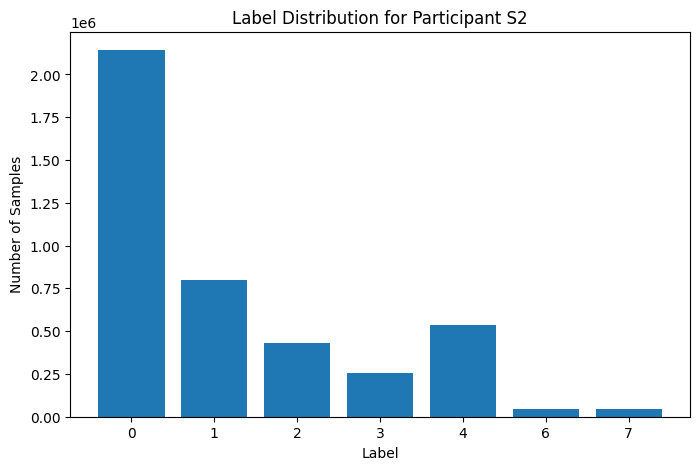

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(unique_labels.astype(str), label_counts)

plt.title("Label Distribution for Participant S2")
plt.xlabel("Label")
plt.ylabel("Number of Samples")

plt.show()

In [24]:
print(s2_data.keys())

dict_keys(['signal', 'label', 'subject'])


In [25]:
print(s2_data['signal']['chest'].keys())
print(s2_data['signal']['wrist'].keys())

dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])
dict_keys(['ACC', 'BVP', 'EDA', 'TEMP'])


In [26]:
for signal_name, signal_data in s2_data['signal']['chest'].items():
    print(signal_name, signal_data.shape)

ACC (4255300, 3)
ECG (4255300, 1)
EMG (4255300, 1)
EDA (4255300, 1)
Temp (4255300, 1)
Resp (4255300, 1)


## Signal Structure of Participant S2

The chest device provides:

- ACC - acceleration
- ECG - electrocardiogram
- EMG - muscle activity
- EDA - electrodermal activity
- Temp - temperature
- Resp - respiration

The wrist device provides:

- ACC - acceleration
- BVP - blood volume pulse
- EDA - electrodermal activity
- TEMP - temperature

 chest signals contain 4,255,300 samples.

 acceleration signal has three channels representing three axes, while the other chest signals contain one channel.

checking the labels

In [27]:
# Checking the unique labels for participant S2

labels = s2_data['label']

unique_labels, label_counts = np.unique(labels, return_counts=True)

print("Unique labels:", unique_labels)
print()

for label, count in zip(unique_labels, label_counts):
    print(f"Label {label}: {count:,} samples")

Unique labels: [0 1 2 3 4 6 7]

Label 0: 2,142,701 samples
Label 1: 800,800 samples
Label 2: 430,500 samples
Label 3: 253,400 samples
Label 4: 537,599 samples
Label 6: 45,500 samples
Label 7: 44,800 samples


In [28]:
# Checking the participant ID

print("Subject:", s2_data['subject'])

Subject: S2


In [29]:
import pandas as pd

# Createing a summary of label counts and percentages

label_summary = pd.DataFrame({
    'label': unique_labels,
    'count': label_counts
})

label_summary['percentage'] = (
    label_summary['count'] / label_summary['count'].sum() * 100
).round(2)

label_summary

,label,count,percentage
0,0,2142701,50.35
1,1,800800,18.82
2,2,430500,10.12
3,3,253400,5.95
4,4,537599,12.63
5,6,45500,1.07
6,7,44800,1.05


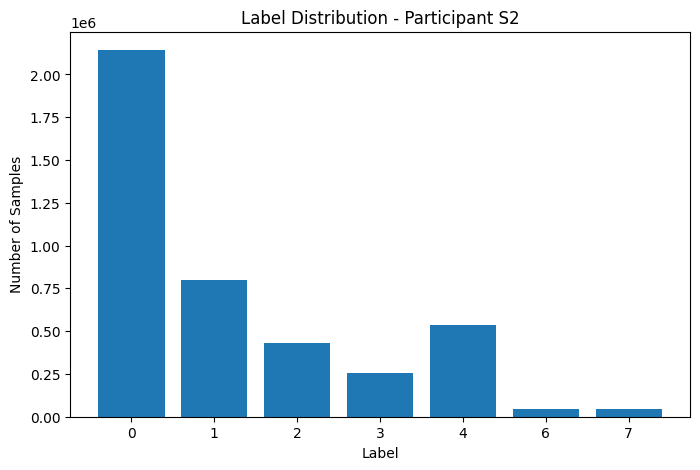

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    label_summary['label'].astype(str),
    label_summary['count']
)

plt.title('Label Distribution - Participant S2')
plt.xlabel('Label')
plt.ylabel('Number of Samples')

plt.show()

inspecting wesad documentation

In [31]:
# Reading the participant specific documentation

s2_readme = os.path.join(s2_path, "S2_readme.txt")

with open(s2_readme, "r", encoding="utf-8", errors="ignore") as f:
    readme_text = f.read()

print(readme_text)

### Personal information ###
Age: 27
Height (cm): 175
Weight (kg): 80
Gender: male
Dominant hand: right

### Study pre-requisites ###
Did you drink coffee today? NO
Did you drink coffee within the last hour? NO
Did you do any sports today? NO
Are you a smoker? NO
Did you smoke within the last hour? NO
Do you feel ill today? NO

### Additional notes ###
The RespiBAN temperature sensor was not fully attached throughout the entire duration of the study protocol.



In [32]:
print("Chest samples:", chest['ECG'].shape[0])
print("Label samples:", len(labels))

print("Match:", chest['ECG'].shape[0] == len(labels))

Chest samples: 4255300
Label samples: 4255300
Match: True


##finding

Data Consistency Check The total number of label samples matches the number of samples in the chest physiological signals.

In [33]:
import pickle
import numpy as np
import pandas as pd
import os

# Map numeric labels to meaningful condition names
condition_map = {
    1: 'baseline',
    2: 'stress',
    3: 'amusement',
    4: 'meditation'
}

# Chest signals we'll aggregate (ACC has 3 axes, so we'll handle it separately)
signal_names = ['ECG', 'EMG', 'EDA', 'Temp', 'Resp']

records = []

for participant in participants:
    p_path = os.path.join(wesad_path, participant, f"{participant}.pkl")

    print(f"Processing {participant}...")

    with open(p_path, "rb") as f:
        p_data = pickle.load(f, encoding="latin1")

    chest = p_data['signal']['chest']
    labels = p_data['label']

    for label_val, condition_name in condition_map.items():
        # Boolean mask: which timestamps belong to this condition
        mask = (labels == label_val)

        if mask.sum() == 0:
            continue  # skip if this participant has no samples for this condition

        row = {
            'participant': participant,
            'condition': condition_name,
            'n_samples': int(mask.sum())
        }

        # Aggregating each single-channel signal
        for sig in signal_names:
            sig_data = chest[sig][mask].flatten()
            row[f'{sig}_mean'] = sig_data.mean()
            row[f'{sig}_std'] = sig_data.std()
            row[f'{sig}_min'] = sig_data.min()
            row[f'{sig}_max'] = sig_data.max()

        # ACC has 3 axes aggregating overall magnitude
        acc_data = chest['ACC'][mask]
        acc_magnitude = np.sqrt((acc_data ** 2).sum(axis=1))
        row['ACC_mean'] = acc_magnitude.mean()
        row['ACC_std'] = acc_magnitude.std()

        records.append(row)

wesad_df = pd.DataFrame(records)
print("\nFinal shape:", wesad_df.shape)
display(wesad_df.head(10))

Processing S10...
Processing S11...
Processing S13...
Processing S14...
Processing S15...
Processing S16...
Processing S17...
Processing S2...
Processing S3...
Processing S4...
Processing S5...
Processing S6...
Processing S7...
Processing S8...
Processing S9...

Final shape: (60, 25)


,participant,condition,n_samples,ECG_mean,ECG_std,ECG_min,ECG_max,EMG_mean,EMG_std,EMG_min,...,Temp_mean,Temp_std,Temp_min,Temp_max,Resp_mean,Resp_std,Resp_min,Resp_max,ACC_mean,ACC_std
0,S10,baseline,826000,0.001306,0.168637,-1.070206,1.421951,-0.002383,0.009828,-0.133255,...,34.290791,0.118036,33.805054,34.577209,0.061296,2.601557,-12.843323,11.723328,0.915466,0.008267
1,S10,stress,507500,0.001261,0.154007,-1.021774,1.075424,-0.002638,0.008917,-0.097916,...,35.425854,0.297905,34.584900,35.778046,0.069402,4.141222,-19.255066,18.611145,0.931382,0.013323
2,S10,amusement,260400,0.001261,0.123294,-0.774948,0.975632,-0.002529,0.007899,-0.057907,...,34.404770,0.054924,34.246582,34.653961,0.053259,2.566898,-9.742737,11.000061,0.939599,0.004599
3,S10,meditation,557200,0.001283,0.118394,-0.644577,0.922852,-0.002728,0.006644,-0.074020,...,34.775669,0.217670,34.359680,35.171936,0.017582,3.796210,-26.930237,12.615967,0.946619,0.004284
4,S11,baseline,826000,0.001072,0.273285,-0.586349,1.499496,-0.003466,0.011655,-0.317551,...,34.360054,0.299944,33.595886,34.863159,0.050219,2.601196,-17.637634,11.122131,0.915342,0.006267
5,S11,stress,476000,0.001012,0.353803,-0.878952,1.499496,-0.003559,0.012737,-0.183334,...,34.561138,0.034465,34.423950,34.736938,0.054178,3.262665,-8.152771,14.350891,0.918163,0.018380
6,S11,amusement,257600,0.001124,0.274017,-0.619034,1.499496,-0.003807,0.008969,-0.212448,...,35.000019,0.049769,34.816956,35.195129,0.043861,3.439840,-15.594482,12.953186,0.924338,0.008282
7,S11,meditation,553701,0.001068,0.285176,-0.744461,1.499496,-0.003674,0.010073,-0.293472,...,34.984692,0.061328,34.804626,35.238495,-0.014968,9.714450,-36.196899,30.084229,0.921766,0.011452
8,S13,baseline,826001,0.001048,0.239528,-0.623840,1.499313,-0.003018,0.013317,-0.174500,...,33.505196,0.252842,32.713989,34.199249,0.052708,4.404113,-20.968628,17.381287,0.917619,0.016400
9,S13,stress,464800,0.001134,0.242502,-0.718002,1.499496,-0.003364,0.011903,-0.164154,...,34.345669,0.183134,33.947906,34.864685,0.064944,7.389154,-27.882385,37.886047,0.925712,0.024233


parsing demographics

In [34]:
import re

demo_records = []

for participant in participants:
    readme_path = os.path.join(wesad_path, participant, f"{participant}_readme.txt")

    with open(readme_path, "r", encoding="utf-8", errors="ignore") as f:
        text = f.read()

    # Extracting each field using regex readme format is consistent across participants
    age_match = re.search(r"Age:\s*(\d+)", text)
    height_match = re.search(r"Height \(cm\):\s*(\d+)", text)
    weight_match = re.search(r"Weight \(kg\):\s*(\d+)", text)
    gender_match = re.search(r"Gender:\s*(\w+)", text)
    hand_match = re.search(r"Dominant hand:\s*(\w+)", text)
    coffee_today_match = re.search(r"Did you drink coffee today\?\s*(\w+)", text)
    coffee_hour_match = re.search(r"Did you drink coffee within the last hour\?\s*(\w+)", text)
    sports_match = re.search(r"Did you do any sports today\?\s*(\w+)", text)
    smoker_match = re.search(r"Are you a smoker\?\s*(\w+)", text)
    ill_match = re.search(r"Do you feel ill today\?\s*(\w+)", text)

    demo_records.append({
        'participant': participant,
        'age': int(age_match.group(1)) if age_match else np.nan,
        'height_cm': int(height_match.group(1)) if height_match else np.nan,
        'weight_kg': int(weight_match.group(1)) if weight_match else np.nan,
        'gender': gender_match.group(1) if gender_match else np.nan,
        'dominant_hand': hand_match.group(1) if hand_match else np.nan,
        'coffee_today': coffee_today_match.group(1) if coffee_today_match else np.nan,
        'coffee_last_hour': coffee_hour_match.group(1) if coffee_hour_match else np.nan,
        'did_sports': sports_match.group(1) if sports_match else np.nan,
        'smoker': smoker_match.group(1) if smoker_match else np.nan,
        'feels_ill': ill_match.group(1) if ill_match else np.nan
    })

demo_df = pd.DataFrame(demo_records)

# Derive BMI a genuinely useful engineered feature from height/weight
demo_df['bmi'] = demo_df['weight_kg'] / ((demo_df['height_cm'] / 100) ** 2)

print("Demographics shape:", demo_df.shape)
display(demo_df)

Demographics shape: (15, 12)


,participant,age,height_cm,weight_kg,gender,dominant_hand,coffee_today,coffee_last_hour,did_sports,smoker,feels_ill,bmi
0,S10,28,178,76,male,right,NO,NO,NO,NO,NO,23.986870
1,S11,26,171,54,female,right,YES,NO,NO,NO,NO,18.467221
2,S13,28,181,82,male,right,NO,NO,NO,NO,NO,25.029761
3,S14,27,180,80,male,right,NO,NO,NO,NO,NO,24.691358
4,S15,28,186,83,male,right,NO,NO,NO,NO,NO,23.991213
5,S16,24,184,69,male,right,NO,NO,NO,NO,NO,20.380435
6,S17,29,165,55,female,right,NO,NO,NO,NO,NO,20.202020
7,S2,27,175,80,male,right,NO,NO,NO,NO,NO,26.122449
8,S3,27,173,69,male,right,NO,NO,NO,NO,NO,23.054562
9,S4,25,175,90,male,right,NO,NO,NO,NO,NO,29.387755


In [35]:
# Merging demographics into the main WESAD table
wesad_df = wesad_df.merge(demo_df, on='participant', how='left')

print("Final merged shape:", wesad_df.shape)
display(wesad_df.head())

Final merged shape: (60, 36)


,participant,condition,n_samples,ECG_mean,ECG_std,ECG_min,ECG_max,EMG_mean,EMG_std,EMG_min,...,height_cm,weight_kg,gender,dominant_hand,coffee_today,coffee_last_hour,did_sports,smoker,feels_ill,bmi
0,S10,baseline,826000,0.001306,0.168637,-1.070206,1.421951,-0.002383,0.009828,-0.133255,...,178,76,male,right,NO,NO,NO,NO,NO,23.986870
1,S10,stress,507500,0.001261,0.154007,-1.021774,1.075424,-0.002638,0.008917,-0.097916,...,178,76,male,right,NO,NO,NO,NO,NO,23.986870
2,S10,amusement,260400,0.001261,0.123294,-0.774948,0.975632,-0.002529,0.007899,-0.057907,...,178,76,male,right,NO,NO,NO,NO,NO,23.986870
3,S10,meditation,557200,0.001283,0.118394,-0.644577,0.922852,-0.002728,0.006644,-0.074020,...,178,76,male,right,NO,NO,NO,NO,NO,23.986870
4,S11,baseline,826000,0.001072,0.273285,-0.586349,1.499496,-0.003466,0.011655,-0.317551,...,171,54,female,right,YES,NO,NO,NO,NO,18.467221


data profiling

In [36]:
# Basic shape and structure
print("Shape (rows, columns):", wesad_df.shape)
print("Total rows:", wesad_df.shape[0])
print("Total columns:", wesad_df.shape[1])

print("\nColumn names and data types:")
print(wesad_df.dtypes)

print("\nGeneral info:")
wesad_df.info()

print("\nFirst 5 rows:")
display(wesad_df.head())

print("\nLast 5 rows:")
display(wesad_df.tail())

Shape (rows, columns): (60, 36)
Total rows: 60
Total columns: 36

Column names and data types:
participant          object
condition            object
n_samples             int64
ECG_mean            float64
ECG_std             float64
ECG_min             float64
ECG_max             float64
EMG_mean            float64
EMG_std             float64
EMG_min             float64
EMG_max             float64
EDA_mean            float64
EDA_std             float64
EDA_min             float64
EDA_max             float64
Temp_mean           float32
Temp_std            float32
Temp_min            float32
Temp_max            float32
Resp_mean           float64
Resp_std            float64
Resp_min            float64
Resp_max            float64
ACC_mean            float64
ACC_std             float64
age                   int64
height_cm             int64
weight_kg             int64
gender               object
dominant_hand        object
coffee_today         object
coffee_last_hour     object
did_sport

,participant,condition,n_samples,ECG_mean,ECG_std,ECG_min,ECG_max,EMG_mean,EMG_std,EMG_min,...,height_cm,weight_kg,gender,dominant_hand,coffee_today,coffee_last_hour,did_sports,smoker,feels_ill,bmi
0,S10,baseline,826000,0.001306,0.168637,-1.070206,1.421951,-0.002383,0.009828,-0.133255,...,178,76,male,right,NO,NO,NO,NO,NO,23.986870
1,S10,stress,507500,0.001261,0.154007,-1.021774,1.075424,-0.002638,0.008917,-0.097916,...,178,76,male,right,NO,NO,NO,NO,NO,23.986870
2,S10,amusement,260400,0.001261,0.123294,-0.774948,0.975632,-0.002529,0.007899,-0.057907,...,178,76,male,right,NO,NO,NO,NO,NO,23.986870
3,S10,meditation,557200,0.001283,0.118394,-0.644577,0.922852,-0.002728,0.006644,-0.074020,...,178,76,male,right,NO,NO,NO,NO,NO,23.986870
4,S11,baseline,826000,0.001072,0.273285,-0.586349,1.499496,-0.003466,0.011655,-0.317551,...,171,54,female,right,YES,NO,NO,NO,NO,18.467221



Last 5 rows:


,participant,condition,n_samples,ECG_mean,ECG_std,ECG_min,ECG_max,EMG_mean,EMG_std,EMG_min,...,height_cm,weight_kg,gender,dominant_hand,coffee_today,coffee_last_hour,did_sports,smoker,feels_ill,bmi
55,S8,meditation,557200,0.001616,0.254229,-0.621826,1.499954,-0.002702,0.007788,-0.192856,...,172,64,female,left,YES,NO,YES,NO,NO,21.633315
56,S9,baseline,826000,0.001615,0.221192,-1.090622,1.499954,-0.002462,0.015076,-0.273331,...,181,75,male,right,NO,NO,NO,NO,YES,22.893074
57,S9,stress,451500,0.001501,0.215519,-0.932968,1.499405,-0.003065,0.014019,-0.135910,...,181,75,male,right,NO,NO,NO,NO,YES,22.893074
58,S9,amusement,260400,0.001522,0.231619,-0.997742,1.499222,-0.003002,0.013211,-0.092789,...,181,75,male,right,NO,NO,NO,NO,YES,22.893074
59,S9,meditation,555100,0.001477,0.207120,-0.965469,1.499222,-0.003114,0.008024,-0.213684,...,181,75,male,right,NO,NO,NO,NO,YES,22.893074


In [37]:
# Unique value checks for key categorical columns
print("Unique participants:", wesad_df['participant'].nunique())
print("Unique conditions:", wesad_df['condition'].unique())
print("Rows per condition:")
print(wesad_df['condition'].value_counts())

print("\nGender distribution (participant-level, not row-level):")
print(demo_df['gender'].value_counts())

Unique participants: 15
Unique conditions: ['baseline' 'stress' 'amusement' 'meditation']
Rows per condition:
condition
baseline      15
stress        15
amusement     15
meditation    15
Name: count, dtype: int64

Gender distribution (participant-level, not row-level):
gender
male      12
female     3
Name: count, dtype: int64


statistics

In [38]:
# Full descriptive statistics for all numeric columns
print("Descriptive statistics (all numeric columns):")
display(wesad_df.describe())

Descriptive statistics (all numeric columns):


,n_samples,ECG_mean,ECG_std,ECG_min,ECG_max,EMG_mean,EMG_std,EMG_min,EMG_max,EDA_mean,...,Resp_mean,Resp_std,Resp_min,Resp_max,ACC_mean,ACC_std,age,height_cm,weight_kg,bmi
count,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,...,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000,60.000000
mean,524510.050000,0.001118,0.258360,-0.802650,1.452962,-0.003032,0.011834,-0.215711,0.213142,4.731530,...,0.049661,3.591901,-17.023926,17.023824,0.932111,0.012736,27.466667,177.600000,73.133333,23.128698
std,203705.434671,0.000295,0.065539,0.309958,0.138341,0.000871,0.004759,0.199990,0.172268,3.417802,...,0.016971,1.470451,7.500712,7.218516,0.015711,0.018085,2.382611,6.574733,10.009261,2.578374
min,253400.000000,0.000261,0.111729,-1.500000,0.922852,-0.004419,0.006644,-1.500000,0.036667,0.709764,...,-0.014968,1.346099,-50.000000,6.794739,0.911941,0.003952,24.000000,165.000000,54.000000,18.467221
25%,389725.000000,0.001034,0.228268,-0.973537,1.499222,-0.003564,0.008553,-0.273983,0.113319,2.119418,...,0.044826,2.601467,-19.401932,11.990356,0.920851,0.006791,26.000000,172.000000,66.000000,21.633315
50%,509600.000000,0.001151,0.262746,-0.743980,1.499496,-0.003058,0.010509,-0.178345,0.178848,3.690591,...,0.052405,3.423034,-16.127777,15.022278,0.927267,0.009685,27.000000,178.000000,75.000000,22.893074
75%,622125.000000,0.001279,0.295780,-0.562626,1.499954,-0.002596,0.013824,-0.102734,0.265572,6.723453,...,0.058748,4.147175,-12.689972,19.676208,0.940247,0.012696,28.000000,184.000000,80.000000,24.691358
max,838600.000000,0.001616,0.446996,-0.324921,1.499954,0.001875,0.037841,-0.053650,1.047180,18.069958,...,0.076064,9.714450,-7.936096,37.886047,0.973638,0.144143,35.000000,189.000000,90.000000,29.387755


In [39]:
# Focused stats: mean, median, mode, variance, std, quartiles for key signal means
key_cols = ['ECG_mean', 'EMG_mean', 'EDA_mean', 'Temp_mean', 'Resp_mean', 'ACC_mean', 'age', 'bmi']

for col in key_cols:
    print(f"\n--- {col} ---")
    print("Mean:", wesad_df[col].mean())
    print("Median:", wesad_df[col].median())
    print("Mode:", wesad_df[col].mode()[0])
    print("Variance:", wesad_df[col].var())
    print("Std Dev:", wesad_df[col].std())
    print("Q1 (25%):", wesad_df[col].quantile(0.25))
    print("Q3 (75%):", wesad_df[col].quantile(0.75))
    print("IQR:", wesad_df[col].quantile(0.75) - wesad_df[col].quantile(0.25))


--- ECG_mean ---
Mean: 0.00111835629103814
Median: 0.0011508039889809208
Mode: 0.0002609939575195313
Variance: 8.718943271946897e-08
Std Dev: 0.0002952785679988796
Q1 (25%): 0.0010343494423981682
Q3 (75%): 0.0012787080782383502
IQR: 0.000244358635840182

--- EMG_mean ---
Mean: -0.003031886666482865
Median: -0.003058445943154649
Mode: -0.004419079448742915
Variance: 7.594882049458611e-07
Std Dev: 0.0008714862046790305
Q1 (25%): -0.0035638201085144024
Q3 (75%): -0.002595721508881416
IQR: 0.0009680985996329866

--- EDA_mean ---
Mean: 4.731529553907612
Median: 3.6905913516990863
Mode: 0.7097644441219344
Variance: 11.681371894976206
Std Dev: 3.4178022024359755
Q1 (25%): 2.11941816889069
Q3 (75%): 6.723453177449349
IQR: 4.604035008558659

--- Temp_mean ---
Mean: 33.954037
Median: 34.1980094909668
Mode: 28.917505
Variance: 1.249215841293335
Std Dev: 1.1176832914352417
Q1 (25%): 33.60300350189209
Q3 (75%): 34.675713539123535
IQR: 1.0727100372314453

--- Resp_mean ---
Mean: 0.04966112534407006

In [40]:
# Summary stats grouped by condition this is the most meaningful cut for WESAD
# (shows how each signal shifts between baseline/stress/amusement/meditation)
condition_summary = wesad_df.groupby('condition')[['ECG_mean', 'EMG_mean', 'EDA_mean', 'Temp_mean', 'Resp_mean']].agg(['mean', 'std'])
display(condition_summary)

ECG_mean            EMG_mean            EDA_mean            \
                mean       std      mean       std      mean       std   
condition                                                                
amusement   0.001142  0.000294 -0.003137  0.000655  4.422057  3.169610   
baseline    0.001149  0.000249 -0.002918  0.000551  3.906262  2.978514   
meditation  0.001171  0.000225 -0.003160  0.000564  4.633399  3.158027   
stress      0.001011  0.000390 -0.002913  0.001447  5.964400  4.226860   

            Temp_mean           Resp_mean            
                 mean       std      mean       std  
condition                                            
amusement   34.087570  0.820322  0.053934  0.009620  
baseline    33.437347  1.512406  0.055849  0.008644  
meditation  34.163872  0.897506  0.039807  0.024092  
stress      34.127342  1.055575  0.049054  0.017350

In [41]:
# Mode for categorical columns
print("Most common gender:", wesad_df['gender'].mode()[0])
print("Most common dominant hand:", wesad_df['dominant_hand'].mode()[0])
print("Most common condition:", wesad_df['condition'].mode()[0])

Most common gender: male
Most common dominant hand: right
Most common condition: amusement


data cleaning

In [42]:
# Missing values check
print("Missing values per column:")
print(wesad_df.isna().sum()[wesad_df.isna().sum() > 0])
print("\nTotal missing values:", wesad_df.isna().sum().sum())

Missing values per column:
Series([], dtype: int64)

Total missing values: 0


In [43]:
# Duplicate check
print("Fully duplicated rows:", wesad_df.duplicated().sum())

# Each participant-condition pair should be unique
dup_combo = wesad_df.duplicated(subset=['participant', 'condition']).sum()
print("Duplicate participant-condition pairs:", dup_combo)

Fully duplicated rows: 0
Duplicate participant-condition pairs: 0


In [44]:
# Structural/consistency checks
print("Unique genders:", wesad_df['gender'].unique())
print("Unique dominant hands:", wesad_df['dominant_hand'].unique())
print("Unique yes/no fields check:")
for col in ['coffee_today', 'coffee_last_hour', 'did_sports', 'smoker', 'feels_ill']:
    print(f"  {col}: {wesad_df[col].unique()}")

# Check n_samples imbalance across conditions (expected due to protocol design, not an error)
print("\nn_samples range by condition:")
print(wesad_df.groupby('condition')['n_samples'].agg(['min', 'max', 'mean']))

Unique genders: ['male' 'female']
Unique dominant hands: ['right' 'left']
Unique yes/no fields check:
  coffee_today: ['NO' 'YES']
  coffee_last_hour: ['NO']
  did_sports: ['NO' 'YES']
  smoker: ['NO' 'YES']
  feels_ill: ['NO' 'YES']

n_samples range by condition:
               min     max           mean
condition                                
amusement   253400  267400  260166.733333
baseline    798000  838600  821846.800000
meditation  511700  563500  550946.600000
stress      430500  507500  465080.066667


In [46]:
import numpy as np

# Sanity check: age/height/weight/bmi within plausible human ranges
print("Age range:", wesad_df['age'].min(), "-", wesad_df['age'].max())
print("Height range (cm):", wesad_df['height_cm'].min(), "-", wesad_df['height_cm'].max())
print("Weight range (kg):", wesad_df['weight_kg'].min(), "-", wesad_df['weight_kg'].max())
print("BMI range:", np.round(wesad_df['bmi'].min(), 2), "-", np.round(wesad_df['bmi'].max(), 2))

Age range: 24 - 35
Height range (cm): 165 - 189
Weight range (kg): 54 - 90
BMI range: 18.47 - 29.39


outlier detection

In [47]:
import numpy as np

# Z-score method on key physiological means + demographics
key_cols = ['ECG_mean', 'EMG_mean', 'EDA_mean', 'Temp_mean', 'Resp_mean', 'ACC_mean', 'age', 'bmi']

for col in key_cols:
    z_scores = (wesad_df[col] - wesad_df[col].mean()) / wesad_df[col].std()
    outliers_z = wesad_df[np.abs(z_scores) > 3]
    print(f"{col}: {outliers_z.shape[0]} outliers (|Z| > 3)")

ECG_mean: 0 outliers (|Z| > 3)
EMG_mean: 1 outliers (|Z| > 3)
EDA_mean: 1 outliers (|Z| > 3)
Temp_mean: 1 outliers (|Z| > 3)
Resp_mean: 1 outliers (|Z| > 3)
ACC_mean: 0 outliers (|Z| > 3)
age: 4 outliers (|Z| > 3)
bmi: 0 outliers (|Z| > 3)


In [48]:
# IQR method on the same columns
for col in key_cols:
    Q1 = wesad_df[col].quantile(0.25)
    Q3 = wesad_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers_iqr = wesad_df[(wesad_df[col] < lower) | (wesad_df[col] > upper)]
    print(f"{col}: {outliers_iqr.shape[0]} outliers (IQR method), bounds=({lower:.4f}, {upper:.4f})")
    if outliers_iqr.shape[0] > 0:
        display(outliers_iqr[['participant', 'condition', col]])

ECG_mean: 5 outliers (IQR method), bounds=(0.0007, 0.0016)


,participant,condition,ECG_mean
14,S14,amusement,0.000541
21,S16,stress,0.000321
22,S16,amusement,0.000536
33,S3,stress,0.000261
45,S6,stress,0.000352


EMG_mean: 1 outliers (IQR method), bounds=(-0.0050, -0.0011)


,participant,condition,EMG_mean
49,S7,stress,0.001875


EDA_mean: 1 outliers (IQR method), bounds=(-4.7866, 13.6295)


...

,participant,condition,ACC_mean
24,S17,baseline,0.973638
31,S2,meditation,0.970883


age: 4 outliers (IQR method), bounds=(23.0000, 31.0000)


,participant,condition,age
40,S5,baseline,35
41,S5,stress,35
42,S5,amusement,35
43,S5,meditation,35


bmi: 4 outliers (IQR method), bounds=(17.0463, 29.2784)


,participant,condition,bmi
36,S4,baseline,29.387755
37,S4,stress,29.387755
38,S4,amusement,29.387755
39,S4,meditation,29.387755


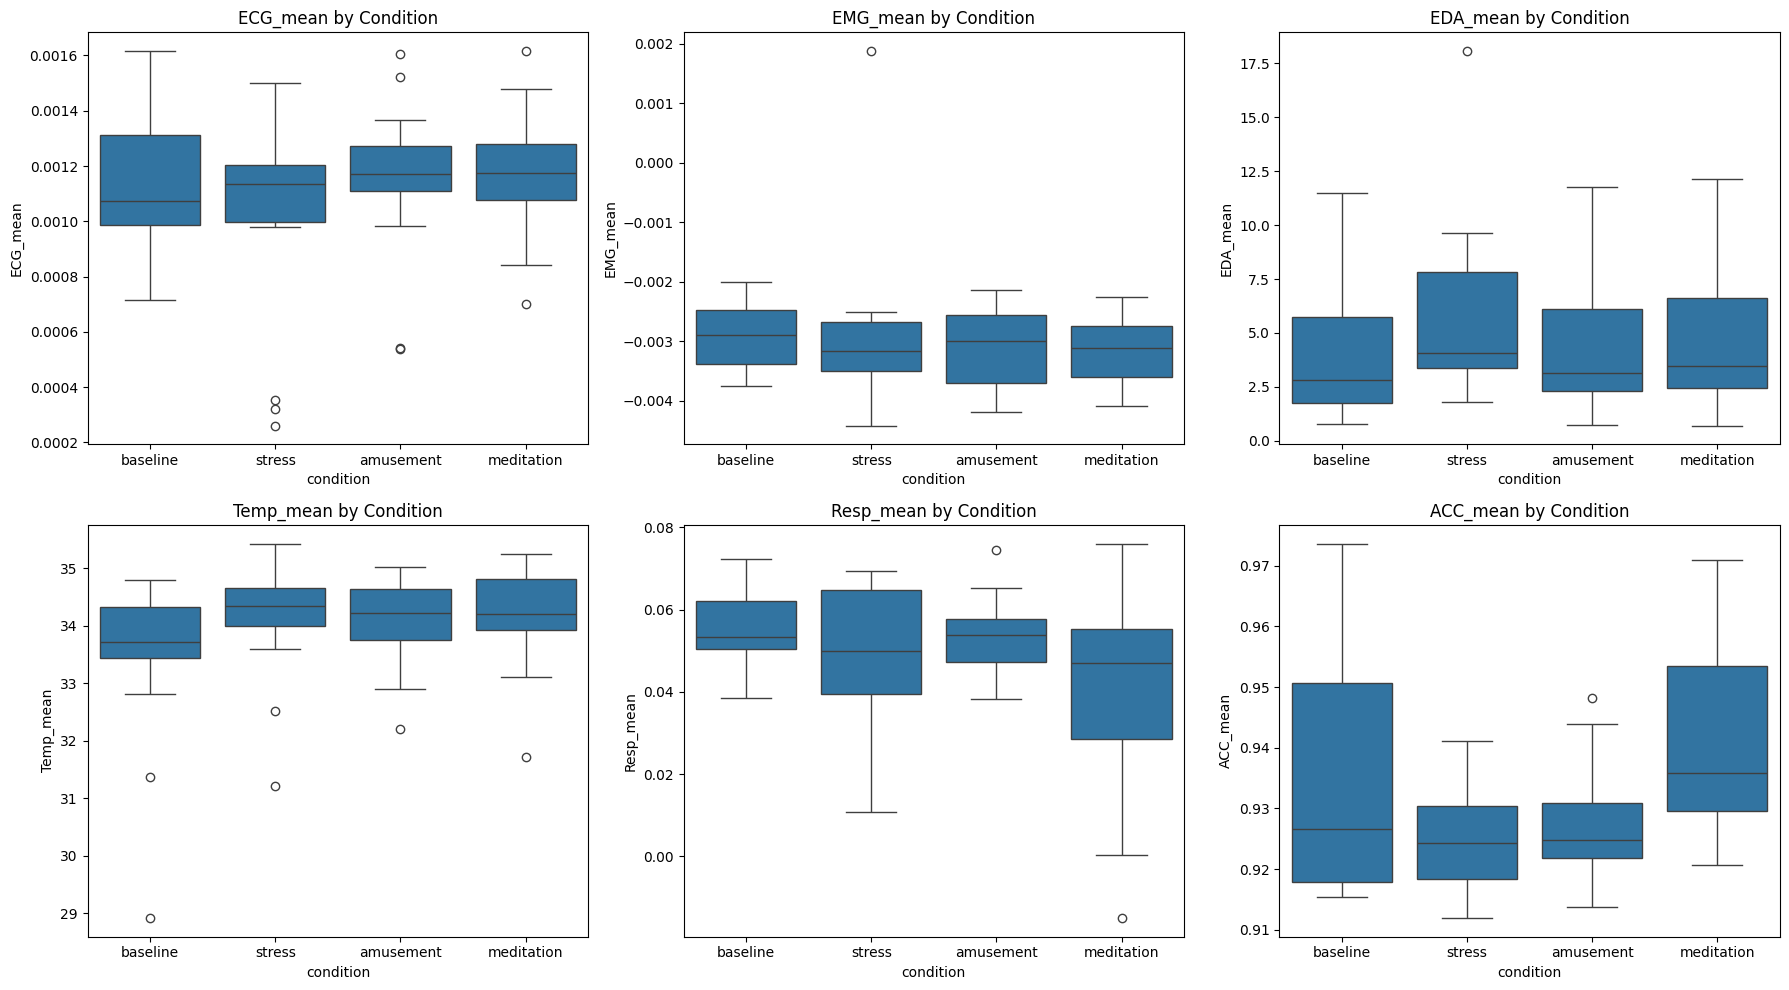

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Box plots across all key signals, split by condition (more informative than overall)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
signal_cols = ['ECG_mean', 'EMG_mean', 'EDA_mean', 'Temp_mean', 'Resp_mean', 'ACC_mean']

for i, col in enumerate(signal_cols):
    ax = axes[i // 3, i % 3]
    sns.boxplot(data=wesad_df, x='condition', y=col, ax=ax)
    ax.set_title(f'{col} by Condition')

plt.tight_layout()
plt.show()

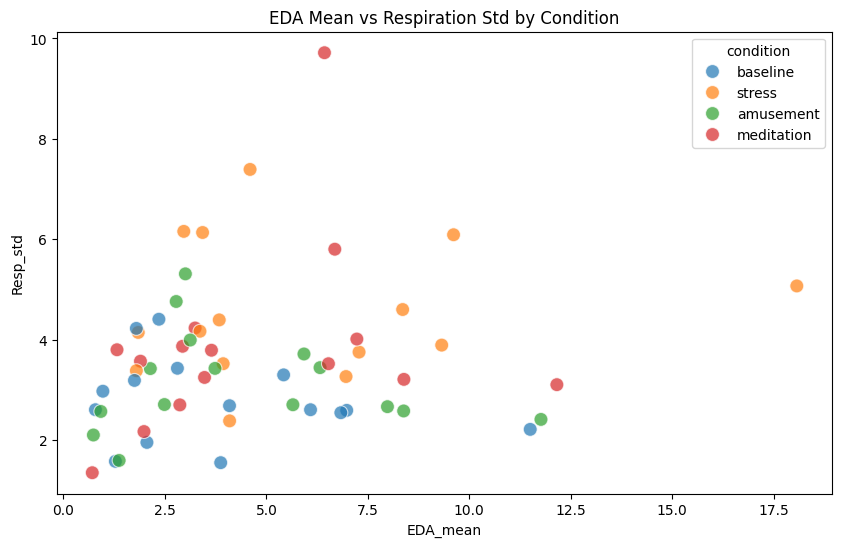

In [50]:
# Scatter plot: EDA_mean vs Resp_std, colored by condition checking for extreme combos
plt.figure(figsize=(10, 6))
sns.scatterplot(data=wesad_df, x='EDA_mean', y='Resp_std', hue='condition', s=100, alpha=0.7)
plt.title('EDA Mean vs Respiration Std by Condition')
plt.show()